# EDA — MoS₂ Memristor IV Data

Phase 2 Exploratory Data Analysis.

## Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'legend.framealpha': 0.9,
    'legend.fontsize': 9,
})
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent          # repo root (assumes notebook is in notebooks/)
DATA = ROOT / "data" / "processed"
RAW  = Path.home() / "Desktop/Imperial/Mres Soft electronics/DATA/15082024"

layer = pd.read_csv(DATA / "layer_sweep.csv")
mem   = pd.read_csv(DATA / "memeffect_sweep.csv")

print(f"layer_sweep : {layer.shape[0]} rows × {layer.shape[1]} cols")
print(f"memeffect   : {mem.shape[0]}  rows × {mem.shape[1]} cols")
layer.head(3)


layer_sweep : 73 rows × 9 cols
memeffect   : 39  rows × 22 cols


,date,layers,filename,id_on_A,id_off_A,on_off_ratio,vgs_min_V,vgs_max_V,n_points
0,16-08,10,AB-AA2-T14-Fast-1-vgs_sweep-vgs_sweep,0.000026,0.000004,7.0,-10.0,10.0,2500
1,16-08,10,AB-AA3-T14-Fast-1-vgs_sweep-vgs_sweep,0.000029,0.000004,8.0,-10.0,10.0,2500
2,16-08,10,AB-AA4-T14-Fast-1-vgs_sweep-vgs_sweep,0.000018,0.000004,5.0,-10.0,10.0,2500


## Section 1 — Layer Sweep Distribution

레이어 수(10–60L)에 따른 on/off ratio 및 I_ON 전류 분포 비교.

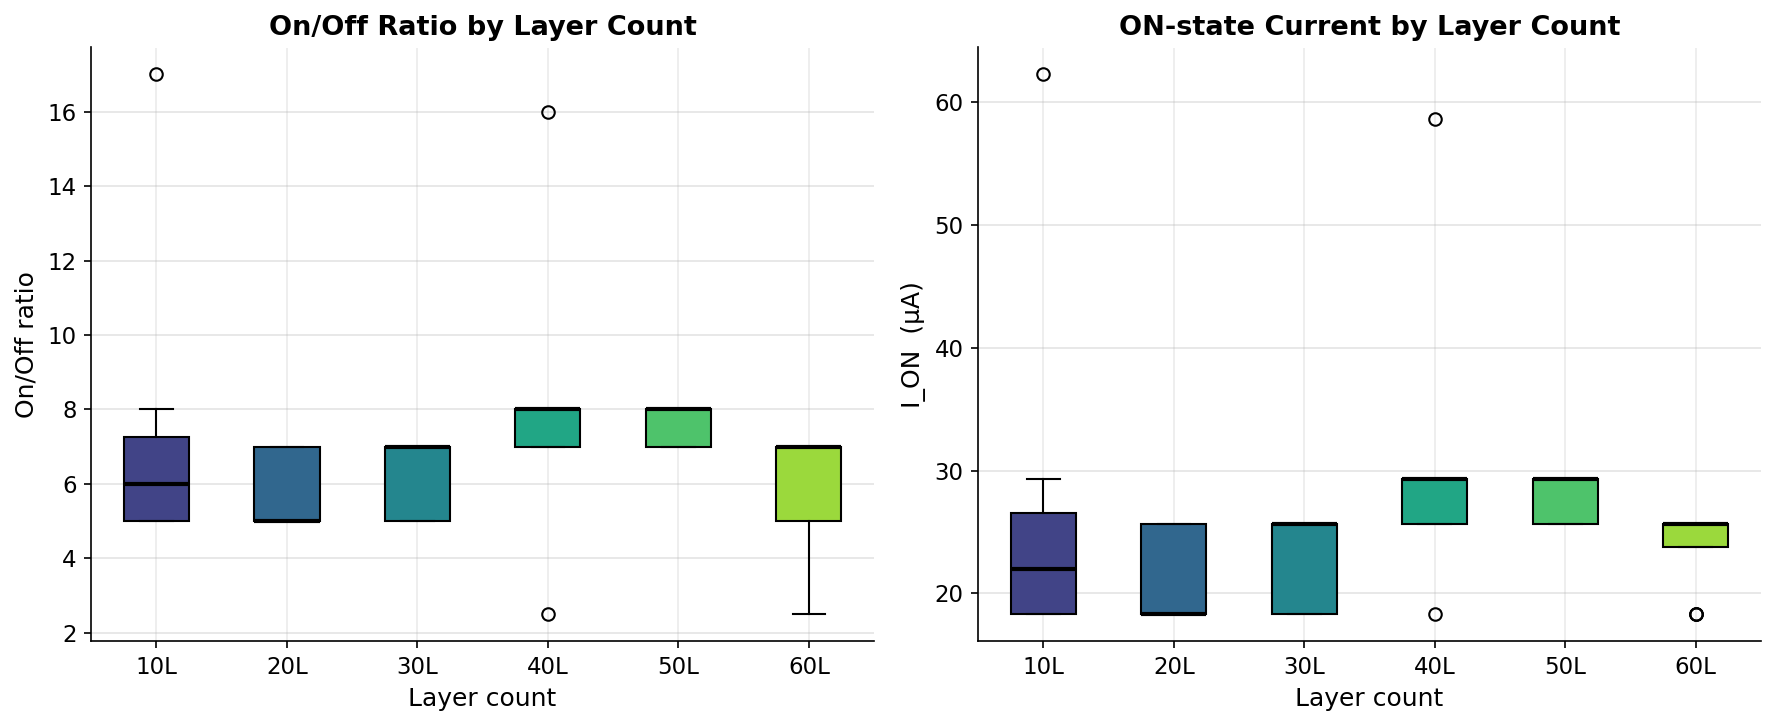

Layer counts per group: {np.int64(10): 12, np.int64(20): 12, np.int64(30): 11, np.int64(40): 14, np.int64(50): 12, np.int64(60): 12}


In [2]:
layer_counts = sorted(layer["layers"].unique())
groups = [layer[layer["layers"] == n]["on_off_ratio"].dropna() for n in layer_counts]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# — on/off ratio boxplot ——————————————————————————————————————————————————————
ax = axes[0]
bp = ax.boxplot(groups, labels=[f"{n}L" for n in layer_counts],
                patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(layer_counts)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_xlabel("Layer count", fontsize=12)
ax.set_ylabel("On/Off ratio", fontsize=12)
ax.set_title("On/Off Ratio by Layer Count", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.35)

# — I_ON boxplot ——————————————————————————————————————————————————————————————
groups_ion = [layer[layer["layers"] == n]["id_on_A"].dropna() * 1e6 for n in layer_counts]

ax = axes[1]
bp2 = ax.boxplot(groups_ion, labels=[f"{n}L" for n in layer_counts],
                 patch_artist=True, notch=False,
                 medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp2["boxes"], colors):
    patch.set_facecolor(color)
ax.set_xlabel("Layer count", fontsize=12)
ax.set_ylabel("I_ON  (μA)", fontsize=12)
ax.set_title("ON-state Current by Layer Count", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.35)

fig.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_s1_layer_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Layer counts per group:", {n: int((layer["layers"]==n).sum()) for n in layer_counts})


## Section 2 — MemEffect IV Curves (Dark Condition)

Run 33 (음전압 0→−20V)과 Run 35 (양전압 0→+20V)의 log-scale IV 곡선. 수직 점선: SET (빨강), RESET (파랑).

In [3]:
def load_iv(fname_pattern: str) -> pd.DataFrame:
    """Load raw IV from 15082024 folder, strip Keithley summary rows."""
    import glob
    matches = glob.glob(str(RAW / f"*{fname_pattern}*.csv"))
    assert len(matches) == 1, f"Expected 1 file, got {len(matches)} for {fname_pattern}"
    fp = matches[0]

    # find header row
    with open(fp, encoding="utf-8-sig") as f:
        for i, line in enumerate(f):
            if "Index" in line and "Voltage" in line:
                header_row = i
                break

    df = pd.read_csv(fp, skiprows=header_row, quotechar='"',
                     encoding="utf-8-sig", dtype=str)
    v_col = [c for c in df.columns if "Voltage" in c][0]
    i_col = [c for c in df.columns if "Current" in c][0]
    idx_col = df.columns[0]

    def is_pos_int(x):
        try: return int(x) > 0
        except: return False

    df = df[df[idx_col].apply(is_pos_int)][[v_col, i_col]].copy()
    df.columns = ["V", "I"]
    df = df.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
    return df


run33 = load_iv("Run 33")
run35 = load_iv("Run 35")
print(f"Run 33: {len(run33)} points  V range [{run33.V.min():.1f}, {run33.V.max():.1f}]")
print(f"Run 35: {len(run35)} points  V range [{run35.V.min():.1f}, {run35.V.max():.1f}]")
run33.head(3)


Run 33: 3999 points  V range [-20.0, 0.0]
Run 35: 3999 points  V range [0.0, 20.0]


,V,I
0,0.000000,-1.036525e-12
1,-0.010005,-1.325190e-11
2,-0.020010,-1.157856e-11


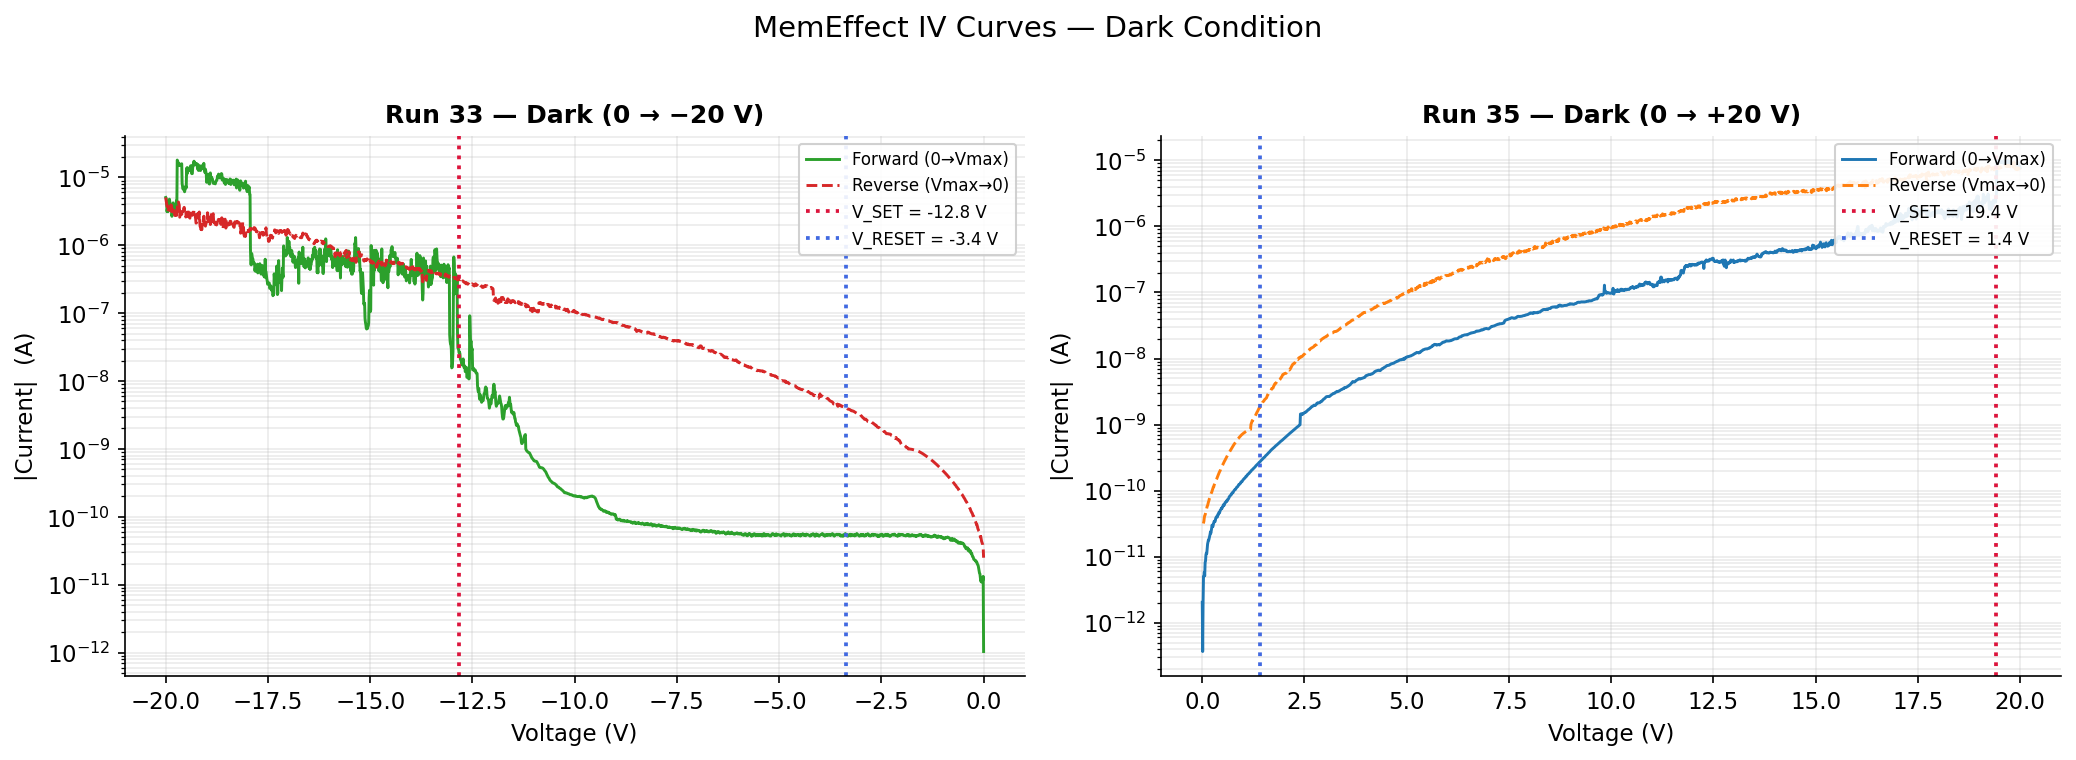

Run 33 | V_SET=-12.83 V | V_RESET=-3.36 V | ON/OFF=1.53e+07 | Hysteresis=9.46 V
Run 35 | V_SET=19.41 V | V_RESET=1.42 V | ON/OFF=2.58e+07 | Hysteresis=17.99 V


In [4]:
# Extract SET/RESET voltages from memeffect_sweep.csv
r33 = mem[mem["filename"].str.contains("Run 33")].iloc[0]
r35 = mem[mem["filename"].str.contains("Run 35")].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_iv_log(ax, df, v_set, v_reset, title, color_fwd, color_rev):
    """Plot IV on log|I| scale, colouring forward/reverse halves separately."""
    V = df["V"].to_numpy()
    I = np.abs(df["I"].to_numpy())
    I = np.where(I == 0, np.nan, I)

    peak_idx = int(np.argmax(np.abs(V)))
    V_fwd, I_fwd = V[:peak_idx + 1], I[:peak_idx + 1]
    V_rev, I_rev = V[peak_idx:], I[peak_idx:]

    ax.semilogy(V_fwd, I_fwd, color=color_fwd, lw=1.4, label="Forward (0→Vmax)")
    ax.semilogy(V_rev, I_rev, color=color_rev, lw=1.4, ls="--", label="Reverse (Vmax→0)")

    if not np.isnan(v_set):
        ax.axvline(v_set,  color="crimson", ls=":", lw=1.8,
                   label=f"V_SET = {v_set:.1f} V")
    if not np.isnan(v_reset):
        ax.axvline(v_reset, color="royalblue", ls=":", lw=1.8,
                   label=f"V_RESET = {v_reset:.1f} V")

    ax.set_xlabel("Voltage (V)", fontsize=11)
    ax.set_ylabel("|Current|  (A)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax.grid(True, which="both", alpha=0.25)
    ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())


plot_iv_log(axes[0], run33,
            v_set=r33["v_set_V"], v_reset=r33["v_reset_V"],
            title="Run 33 — Dark (0 → −20 V)",
            color_fwd="#2ca02c", color_rev="#d62728")

plot_iv_log(axes[1], run35,
            v_set=r35["v_set_V"], v_reset=r35["v_reset_V"],
            title="Run 35 — Dark (0 → +20 V)",
            color_fwd="#1f77b4", color_rev="#ff7f0e")

fig.suptitle("MemEffect IV Curves — Dark Condition", fontsize=14, y=1.01)
fig.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_s2_iv_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Run 33 | V_SET={r33.v_set_V:.2f} V | V_RESET={r33.v_reset_V:.2f} V "
      f"| ON/OFF={r33.on_off_ratio:.2e} | Hysteresis={r33.hysteresis_window_V:.2f} V")
print(f"Run 35 | V_SET={r35.v_set_V:.2f} V | V_RESET={r35.v_reset_V:.2f} V "
      f"| ON/OFF={r35.on_off_ratio:.2e} | Hysteresis={r35.hysteresis_window_V:.2f} V")


## Section 3 — Feature Correlation (layer_sweep)

layer_sweep numeric feature들 간의 Pearson 상관계수 heatmap.

In [ ]:
import matplotlib.colors as mcolors

numeric_cols = ["layers", "id_on_A", "id_off_A", "on_off_ratio",
                "vgs_min_V", "vgs_max_V", "n_points"]
corr = layer[numeric_cols].corr()

# nicer labels
label_map = {
    "layers": "Layers", "id_on_A": "I_ON (A)", "id_off_A": "I_OFF (A)",
    "on_off_ratio": "ON/OFF ratio", "vgs_min_V": "V_min (V)",
    "vgs_max_V": "V_max (V)", "n_points": "n_points"
}
corr.index   = [label_map.get(c, c) for c in corr.index]
corr.columns = [label_map.get(c, c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(8, 5.5))
cmap = plt.cm.RdBu_r
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")

n = len(corr)
ax.set_xticks(range(n)); ax.set_xticklabels(corr.columns, rotation=35, ha="right", fontsize=10)
ax.set_yticks(range(n)); ax.set_yticklabels(corr.index, fontsize=10)

for i in range(n):
    for j in range(n):
        val = corr.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)

ax.set_title("layer_sweep — Feature Correlation Heatmap", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_s3_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4 — Data Quality Summary

switching_state 분포 파이차트 및 memeffect_sweep 결측값 현황.

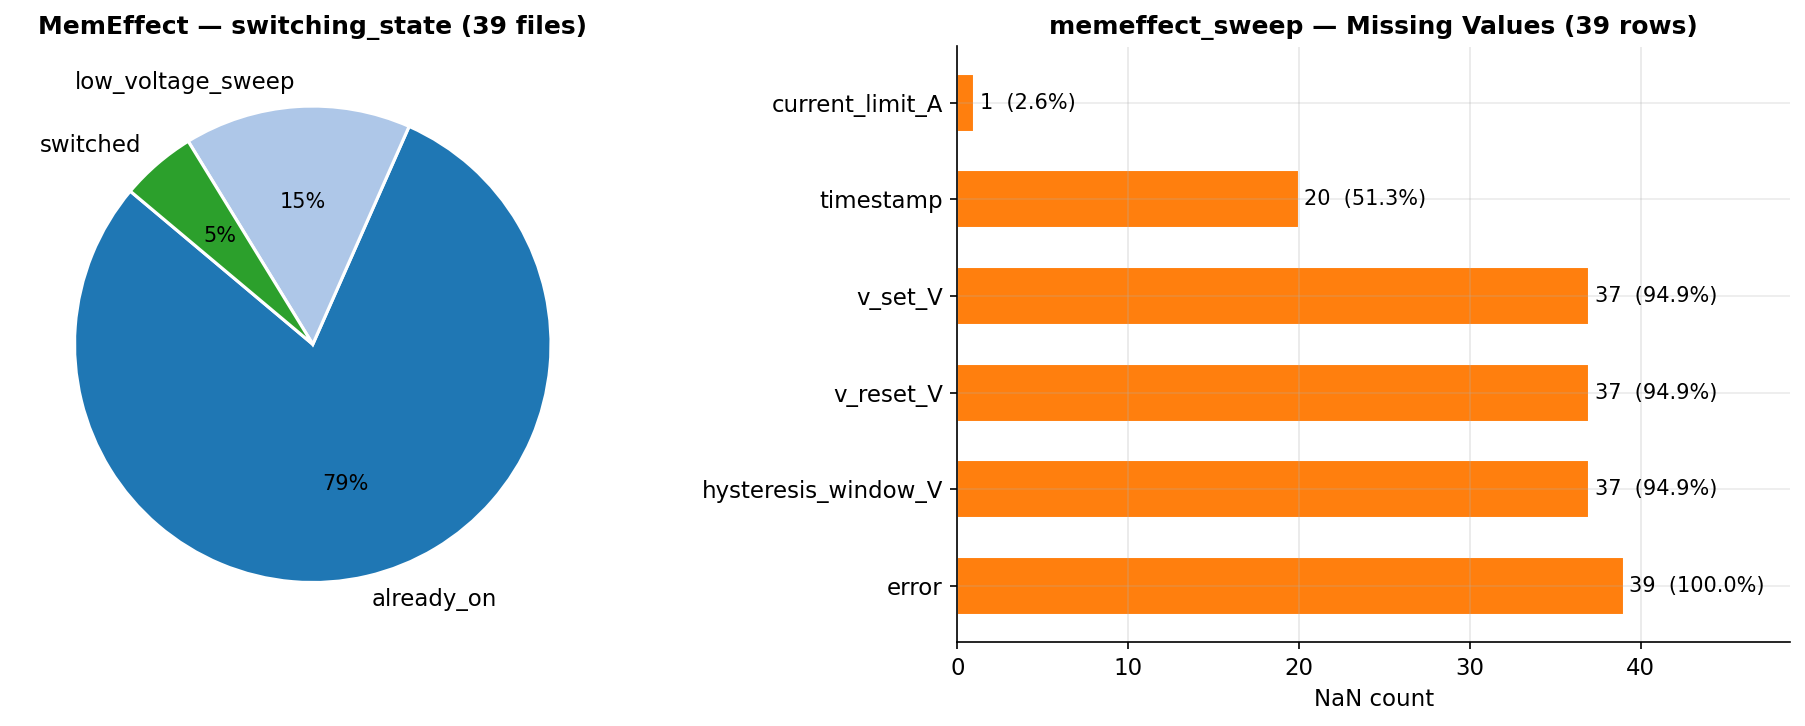


=== NaN counts — memeffect_sweep ===
                     NaN count  NaN %
current_limit_A              1    2.6
timestamp                   20   51.3
v_set_V                     37   94.9
v_reset_V                   37   94.9
hysteresis_window_V         37   94.9
error                       39  100.0

layer_sweep: no missing values


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Pie chart: switching_state ————————————————————————————————————————————————
state_counts = mem["switching_state"].value_counts()
state_colors = {
    "switched":           "#2ca02c",
    "already_on":         "#1f77b4",
    "low_voltage_sweep":  "#aec7e8",
    "no_switching_detected": "#d62728",
}
colors_pie = [state_colors.get(s, "#cccccc") for s in state_counts.index]

wedges, texts, autotexts = axes[0].pie(
    state_counts.values,
    labels=state_counts.index,
    colors=colors_pie,
    autopct="%1.0f%%",
    startangle=140,
    textprops=dict(fontsize=11),
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(10)
axes[0].set_title(f"MemEffect — switching_state ({len(mem)} files)", fontsize=12, fontweight="bold")

# — NaN count table ————————————————————————————————————————————————————————————
nan_counts = mem.isnull().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=True)
pct = (nan_counts / len(mem) * 100).round(1)

ax = axes[1]
bars = ax.barh(nan_counts.index, nan_counts.values,
               color="#ff7f0e", edgecolor="white", height=0.6)
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())}  ({p}%)",
            va="center", fontsize=10)
ax.set_xlabel("NaN count", fontsize=11)
ax.set_title(f"memeffect_sweep — Missing Values ({len(mem)} rows)", fontsize=12, fontweight="bold")
ax.set_xlim(0, len(mem) * 1.25)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

fig.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_s4_quality.png", dpi=150, bbox_inches="tight")
plt.show()

# Print NaN summary table
print("\n=== NaN counts — memeffect_sweep ===")
nan_df = pd.DataFrame({"NaN count": nan_counts, "NaN %": pct})
print(nan_df.to_string())

# layer_sweep NaN check
layer_nan = layer.isnull().sum()
layer_nan = layer_nan[layer_nan > 0]
if len(layer_nan) == 0:
    print("\nlayer_sweep: no missing values")
else:
    print("\n=== NaN counts — layer_sweep ===")
    print(layer_nan.to_string())
